In [100]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer

In [101]:
path_x_train  = "df_procesado/X_train.csv"
path_y_train  = "df_procesado/y_train.csv"
path_x_test  = "df_procesado/X_test.csv"
path_y_test  = "df_procesado/y_test.csv"

# 2. Cargar los datasets
df_X_train = pd.read_csv(path_x_train, keep_default_na=False)
df_X_test = pd.read_csv(path_x_test, keep_default_na=False)

df_y_train = pd.read_csv(path_y_train).squeeze()
df_y_test = pd.read_csv(path_y_test).squeeze()

# 3. Verificación de carga
print("==============================================")
print("        DATASET CARGADO CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de x train:  {df_X_train.shape[0]} filas, {df_X_train.shape[1]} columnas")
print(f"Dimensiones de y Train: {df_y_train.shape[0]} filas, 1 columna")
print(f"Dimensiones de x Test:  {df_X_test.shape[0]} filas, {df_X_test.shape[1]} columnas")
print(f"Dimensiones de y Train: {df_y_test.shape[0]} filas, 1 columna")

print("\n--- Tipos de datos en Train ---")
print(df_X_train)
print(df_y_train)


print("\n--- Primeras 5 filas de Train ---")
display(df_X_train.head())
print(df_y_train)


        DATASET CARGADO CON ÉXITO           
Dimensiones de x train:  39061 filas, 1 columnas
Dimensiones de y Train: 39061 filas, 1 columna
Dimensiones de x Test:  9766 filas, 1 columnas
Dimensiones de y Train: 9766 filas, 1 columna

--- Tipos de datos en Train ---
                                         statement_clean
0                                                       
1      close eye count ten ill feel blank like way ba...
2      feel nothing nothing almost flunked college tw...
3      hey recently discovered zyrtec made depression...
4      wahh csi anywhere dvr ed love money though gon...
...                                                  ...
39056                       today people like lot action
39057  fucking cold ð© hate working tf sign ð­why...
39058  nose clogged dried anyone get stressanxiety ne...
39059                          broooooo kim jibeooommmmm
39060  fuck toxic positivity every right feel angry p...

[39061 rows x 1 columns]
0            Normal
1  

,statement_clean
0,
1,close eye count ten ill feel blank like way ba...
2,feel nothing nothing almost flunked college tw...
3,hey recently discovered zyrtec made depression...
4,wahh csi anywhere dvr ed love money though gon...


0            Normal
1        Depression
2        Depression
3        Depression
4            Normal
            ...    
39056        Normal
39057    Depression
39058       Anxiety
39059        Normal
39060    Depression
Name: status_group, Length: 39061, dtype: object


In [102]:
pipeline_lr = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=46
    ))
])

param_grid_lr = {
    "vectorizer__max_features": [10000, 20000],
    "vectorizer__min_df": [5],
    "vectorizer__max_df": [0.8, 0.9],
    "vectorizer__ngram_range": [(1,1), (1,2)],
    "classifier__C": [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

In [103]:
pipeline_svm = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=46
    ))
])

param_grid_svm = {
    "vectorizer__max_features": [10000, 20000],
    "vectorizer__min_df": [5],
    "vectorizer__max_df": [0.8, 0.9],
    "vectorizer__ngram_range": [(1,1), (1,2)],
    "classifier__C": [0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

In [104]:
pipeline_lr_tfidf = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=46
    ))
])

param_grid_lr_tfidf = { 
    "vectorizer__max_features": [10000, 20000],
    "vectorizer__min_df": [5],
    "vectorizer__max_df": [0.8, 0.9],
    "vectorizer__ngram_range": [(1,1), (1,2)],
    "classifier__C": [0.01, 0.1, 1, 10]
}

grid_lr_tfidf = GridSearchCV(
    pipeline_lr_tfidf,
    param_grid=param_grid_lr_tfidf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

In [105]:
pipeline_svm_tfidf = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", LinearSVC(
            class_weight="balanced",
            random_state=46
    ))
])
param_grid_svm_tfidf = {
    "vectorizer__max_features": [10000, 20000],
    "vectorizer__min_df": [5],
    "vectorizer__max_df": [0.8, 0.9],
    "vectorizer__ngram_range": [(1,1), (1,2)],
    "classifier__C": [0.01, 0.1, 1, 10]
}

grid_svm_tfidf = GridSearchCV(
    pipeline_svm_tfidf,
    param_grid_svm_tfidf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

In [106]:
df_X_train["statement_clean"] = (
    df_X_train["statement_clean"]
    .fillna("")
    .astype(str)
)

df_X_test["statement_clean"] = (
    df_X_test["statement_clean"]
    .fillna("")
    .astype(str)
)

In [107]:
print("Entrenando Regresión Logística...")
grid_lr.fit(df_X_train["statement_clean"], df_y_train)

print("Entrenando Linear SVM...")
grid_svm.fit(df_X_train["statement_clean"], df_y_train)

Entrenando Regresión Logística...
Entrenando Linear SVM...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=46))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'vectorizer__max_df': [0.8, 0.9], 'vectorizer__max_features': [10000, 20000], 'vectorizer__min_df': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for ca

In [108]:
print("Entrenando Regresión Logística con tfidf...")
grid_lr_tfidf.fit(df_X_train["statement_clean"], df_y_train)
print("Entrenando Linear SVM con tfidf...")
grid_svm_tfidf.fit(df_X_train["statement_clean"], df_y_train)

Entrenando Regresión Logística con tfidf...
Entrenando Linear SVM con tfidf...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=46))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'vectorizer__max_df': [0.8, 0.9], 'vectorizer__max_features': [10000, 20000], 'vectorizer__min_df': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for ca

In [109]:
print("REGRESIÓN LOGÍSTICA")

print("Mejor F1:", round(grid_lr.best_score_,4))
print("Mejores parámetros:")
print(grid_lr.best_params_)

print("\nLINEAR SVM")

print("Mejor F1:", round(grid_svm.best_score_,4))
print("Mejores parámetros:")
print(grid_svm.best_params_)

print("\n REGRESIÓN LOGÍSTICA TFIDF")

print("Mejor F1:", round(grid_lr_tfidf.best_score_,4))
print("Mejores parámetros:")
print(grid_lr_tfidf.best_params_)

print("\nLINEAR SVM")

print("Mejor F1:", round(grid_svm_tfidf.best_score_,4))
print("Mejores parámetros:")
print(grid_svm_tfidf.best_params_)

REGRESIÓN LOGÍSTICA
Mejor F1: 0.8839
Mejores parámetros:
{'classifier__C': 1, 'vectorizer__max_df': 0.8, 'vectorizer__max_features': 20000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}

LINEAR SVM
Mejor F1: 0.8836
Mejores parámetros:
{'classifier__C': 0.1, 'vectorizer__max_df': 0.8, 'vectorizer__max_features': 20000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}

 REGRESIÓN LOGÍSTICA TFIDF
Mejor F1: 0.8828
Mejores parámetros:
{'classifier__C': 10, 'vectorizer__max_df': 0.8, 'vectorizer__max_features': 20000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}

LINEAR SVM
Mejor F1: 0.8835
Mejores parámetros:
{'classifier__C': 1, 'vectorizer__max_df': 0.8, 'vectorizer__max_features': 20000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}


In [110]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Linear SVM",
        "Regresión Logística TF-IDF",
        "Linear SVM TF-IDF"
    ],
    "F1 Cross Validation": [
        grid_lr.best_score_,
        grid_svm.best_score_,
        grid_lr_tfidf.best_score_,
        grid_svm_tfidf.best_score_
    ]
})

# Ordenar de mejor a peor
comparacion = comparacion.sort_values(
    by="F1 Cross Validation",
    ascending=False
).reset_index(drop=True)

print("\nComparación de modelos:")
print(comparacion.to_string(index=False))

# Seleccionar automáticamente el mejor modelo
modelos = {
    "Regresión Logística": grid_lr,
    "Linear SVM": grid_svm,
    "Regresión Logística TF-IDF": grid_lr_tfidf,
    "Linear SVM TF-IDF": grid_svm_tfidf
}

nombre = comparacion.loc[0, "Modelo"]
mejor_modelo = modelos[nombre].best_estimator_

print(f"\nModelo seleccionado: {nombre}")
print(f"F1 Cross Validation: {comparacion.loc[0, 'F1 Cross Validation']:.4f}")


Comparación de modelos:
                    Modelo  F1 Cross Validation
       Regresión Logística             0.883948
                Linear SVM             0.883650
         Linear SVM TF-IDF             0.883525
Regresión Logística TF-IDF             0.882756

Modelo seleccionado: Regresión Logística
F1 Cross Validation: 0.8839


In [111]:
pred = mejor_modelo.predict(df_X_test["statement_clean"])

print("RESULTADOS EN TEST")

print("Accuracy :", round(accuracy_score(df_y_test, pred), 4))
print("Precision:", round(precision_score(df_y_test, pred, average="macro"), 4))
print("Recall   :", round(recall_score(df_y_test, pred, average="macro"), 4))
print("F1-score :", round(f1_score(df_y_test, pred, average="macro"), 4))

print("\nClassification Report:\n")
print(classification_report(df_y_test, pred))

RESULTADOS EN TEST
Accuracy : 0.9137
Precision: 0.8853
Recall   : 0.892
F1-score : 0.8883

Classification Report:

              precision    recall  f1-score   support

     Anxiety       0.81      0.81      0.81      1286
  Depression       0.95      0.92      0.94      5211
      Normal       0.89      0.95      0.92      3269

    accuracy                           0.91      9766
   macro avg       0.89      0.89      0.89      9766
weighted avg       0.91      0.91      0.91      9766



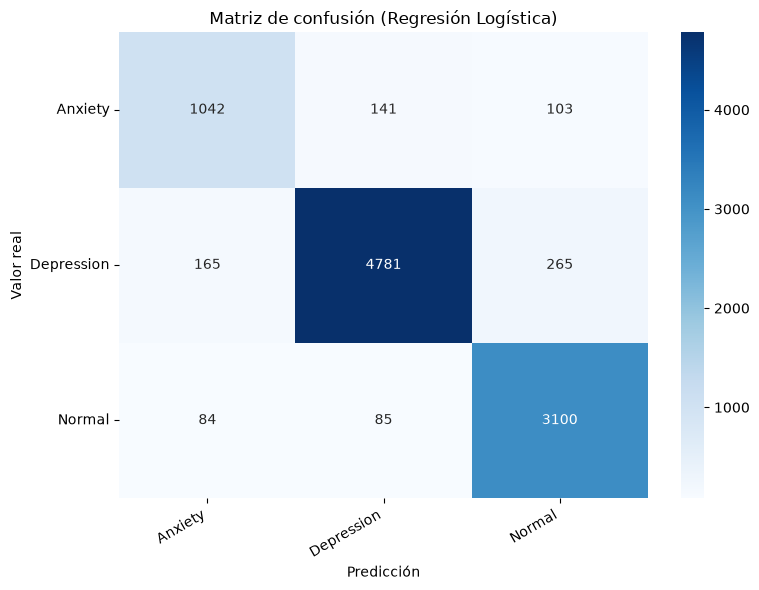

In [112]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusión
cm = confusion_matrix(df_y_test, pred)

# Obtener las clases en el orden correcto
clases = mejor_modelo.classes_

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)

plt.title(f"Matriz de confusión ({nombre})")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()